# CS-546 Final Project
## 
## Authors: Tobi Kohn & Trent VanHawkins

### Introduction
Plant pathogens displaying Long-Distance Dispersal (LDD) pose a substantial threat to global food security and economics. The Pacific Northwest, in particular, is a world leader in the production of Hops. 

Pathogens displaying Long-Distance Dispersal (LDD) pose a substantial threat to global food security and agronomics. Agricultural managemenet practices exist often include treatments such as fungicide, herbicide, or pesticid; however,  airborne pathogens can readily invade across abritrary jurisdictional boundaries and propogate new infections where management practices differ. Anually, these diseases poses an estimated $220 Billion in harvest loss [CITE]. 

The Willamette Valley is a global leader in the production of Hops (*Humulus lupulus*). Powdery Mildew (*Podosphaera macularis*) is a regionally important diesease of hops, and can lead to total crop loss if not managed appropriately [CITE]. The disease appeared in the Willamette Valley for the first time in 1998, and has occured in every subsequent year up until the present.

Models of disease spread are a classical focus of pathology research. In recent years, however, these classical models have been placed into the context of spatially explicit networks, which use stochastic models to learn network structures across discrete 

### Methods
#### The Data
#### How we learned the network structure
#### How we estimated the edge-weights
#### Estimating source-strength (outward degree) and an investigation of its properties
#### Analysis of source-strength stratified by yard-type and grower characteristics (sprays & pruning)
#### 

### Results
#### Source Strength behaviors
#### Soruce stregnth stratified analysis
#### Centrality analysis

### Discussion
#### General summary of conclusions
#### Limitations
#### Future directions

In [1]:
import igraph as ig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cairo
import contextily as ctx
import networkx as nx

# Read in the adjacency matrices from the CSV files
apr_may = pd.read_csv('../reports/networks/network_may_jun.csv', index_col=0, header=0)
may_jun = pd.read_csv('../reports/networks/network_may_jun.csv', index_col=0, header=0)
jun_jul = pd.read_csv('../reports/networks/network_jun_jul.csv', index_col=0, header=0)

#Read in the metadata
meta = pd.read_csv('../data/processed/clean_summary.csv', index_col=0, header=0)
meta["date"] = pd.to_datetime(meta["date"])

# Subset to 2017
meta_2017 = meta.loc[meta["year"] == 2017, ["field_id", "centroid_lat", "centroid_long", "initial_strain", "plant_type"]]
meta_2017.drop_duplicates(subset="field_id", keep="first", inplace=True)

#Write a function to build an igraph with metadata
def build_graph(adj_df, meta_df):
    # Build graph
    g = ig.Graph.Weighted_Adjacency(adj_df.to_numpy().transpose(), mode="directed", attr="weight", loops=False)
    
    # Add node names
    g.vs["name"] = adj_df.columns.tolist()
    
    # Add metadata attributes
    meta_indexed = meta_df.set_index("field_id")
    for col in meta_indexed.columns:
        g.vs[col] = [meta_indexed.loc[int(v["name"]), col] for v in g.vs]
    
    return g

apr_may_g = build_graph(apr_may, meta_2017)
may_jun_g = build_graph(may_jun, meta_2017)
jun_jul_g = build_graph(jun_jul, meta_2017)


In [2]:
out_apr_may = apr_may_g.strength(mode = "out", weights="weight")
out_may_jun = may_jun_g.strength(mode = "out", weights="weight")
out_jun_jul = jun_jul_g.strength(mode = "out", weights="weight")

In [ ]:
def plot_network(g, title="", weight_percentile=75):
    
    # Filter edges below percentile threshold
    weights = [e["weight"] for e in g.es]
    threshold = np.percentile(weights, weight_percentile)
    g_filtered = g.copy()
    g_filtered.delete_edges([e.index for e in g_filtered.es if e["weight"] < threshold])

    # Remove isolated nodes (optional)
    g_filtered.delete_vertices([v.index for v in g_filtered.vs if g_filtered.degree(v.index) == 0])

    # Node properties
    pos = {v["name"]: (v["centroid_long"], v["centroid_lat"]) for v in g_filtered.vs}
    node_colors = ["crimson" if v["plant_type"] == "R6" else "steelblue" for v in g_filtered.vs]
    weighted_outdegree = g_filtered.strength(mode="out", weights="weight")
    # Normalise to a size range
    min_size, max_size = 100, 1000
    w_min, w_max = min(weighted_outdegree), max(weighted_outdegree)
    node_sizes = [min_size + (w - w_min) / (w_max - w_min + 1e-9) * (max_size - min_size) 
                for w in weighted_outdegree]

    # Edge properties
    edge_weights = [e["weight"] for e in g_filtered.es]
    w_min, w_max = min(edge_weights), max(edge_weights)
    edge_colors = [(0, 0, 0, (e["weight"] - w_min) / (w_max - w_min + 1e-9)) for e in g_filtered.es]  

    # Convert to networkx for plotting
    G = nx.DiGraph()
    for v in g_filtered.vs:
        G.add_node(v["name"])
    for e in g_filtered.es:
        G.add_edge(g_filtered.vs[e.source]["name"], g_filtered.vs[e.target]["name"], weight=e["weight"])

    fig, ax = plt.subplots(figsize=(12, 10))

    nx.draw_networkx_nodes(G, pos=pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.75)
    nx.draw_networkx_labels(G, pos=pos, ax=ax, font_size=6, font_color="white")
    nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color=edge_colors,
                           arrows=True, arrowsize=15, width=1.5,
                           connectionstyle="arc3,rad=0.1")  # slight curve to show directionality

    # Basemap
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Voyager)

    # Legend
    from matplotlib.lines import Line2D
    legend = [Line2D([0], [0], marker="o", color="w", markerfacecolor="crimson", markersize=10, label="R6"),
              Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=10, label="Non-R6")]
    ax.legend(handles=legend, loc="upper left")

    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_network(apr_may_g, title="Apr–May", weight_percentile=50)
plot_network(may_jun_g, title="May–Jun", weight_percentile=50)
plot_network(jun_jul_g, title="Jun–Jul", weight_percentile=50)

In [130]:
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 150)
non_R6 = meta_2017[meta_2017["plant_type"] == "non-R6"]["field_id"]
R6 = meta_2017[meta_2017["plant_type"] == "R6"]["field_id"]
non_V6 = meta_2017[meta_2017["initial_strain"] == "non-V6"]["field_id"]
V6 = meta_2017[meta_2017["initial_strain"] == "V6"]["field_id"]

labels = jun_jul.index
in_deg = jun_jul.sum(axis=1).to_numpy()
out_deg  = jun_jul.sum(axis=0).to_numpy()

In [131]:
R6_goes_to = np.concat([non_R6, R6])
non_R6_V6_goes_to = np.concat([non_R6, R6])
non_R6_non_V6_goes_to = np.concat([non_R6])

In [90]:
def degree_distribution(degrees: np.ndarray, bins = 10):

  y, edges = np.histogram(degrees, bins=bins)
  x = 0.5 * (edges[:-1] + edges[1:])
  plt.loglog(x, y, 'b')
  plt.xlabel("k")
  plt.ylabel("N(k)")
  plt.show()

  pl_fit = ig.statistics.power_law_fit(degrees)
  print(f"The power law exponent α is {pl_fit.alpha}")
  print(f"the power law fit p-value is {pl_fit.p}")
  return pl_fit

In [170]:
gx = jun_jul_g.to_networkx()
((nx.adjacency_spectrum(gx, weight="weight")))

array([ 1.32701661e-02+0.00000000e+00j, -1.07663773e-02+0.00000000e+00j,
        9.37991783e-03+0.00000000e+00j, -7.54759282e-03+0.00000000e+00j,
        3.55215824e-03+0.00000000e+00j, -3.68866529e-03+0.00000000e+00j,
       -2.72695881e-03+0.00000000e+00j, -1.43565915e-03+0.00000000e+00j,
        1.54981121e-03+0.00000000e+00j, -4.89162912e-04+0.00000000e+00j,
       -2.06719420e-04+0.00000000e+00j, -3.21866707e-04+7.46575510e-05j,
       -3.21866707e-04-7.46575510e-05j, -1.81380177e-04+0.00000000e+00j,
        3.18705130e-05+5.98356609e-05j,  3.18705130e-05-5.98356609e-05j,
       -7.63549988e-05+2.52440571e-05j, -7.63549988e-05-2.52440571e-05j,
        2.83362854e-05+0.00000000e+00j, -5.17042794e-06+0.00000000e+00j,
       -9.83154084e-10+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000

In [ ]:




if isinstance(gx, nx.classes.digraph.DiGraph):
    indeg_katz_scores = nx.katz_centrality(gx, alpha=0.01)
    outdeg_katz_scores = nx.katz_centrality(gx.reverse(), alpha=0.01)





In [ ]:
indeg_katz_series = pd.Series(indeg_katz_scores, index=list(labels))
outdeg_katz_series = pd.Series(outdeg_katz_scores, index=list(labels))

outdeg_katz_series.value_counts()




0.065433    90
0.164400    15
0.164400     5
Name: count, dtype: int64

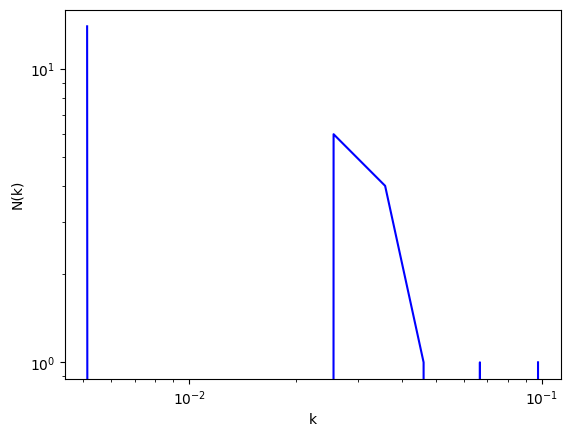

The power law exponent α is 3.628664402115176
the power law fit p-value is 0.792


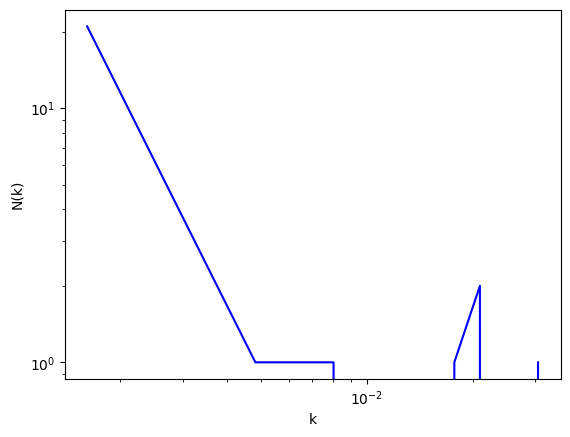

The power law exponent α is 1.6848382385163605
the power law fit p-value is 0.038


In [75]:
R6_in_pl_fit = degree_distribution(in_deg[R6.index])
R6_out_pl_fit = degree_distribution(out_deg[R6.index])

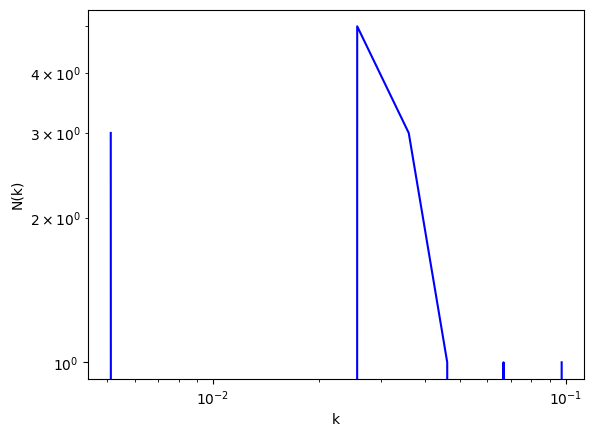

The power law exponent α is 3.411603616765388
the power law fit p-value is 0.8012


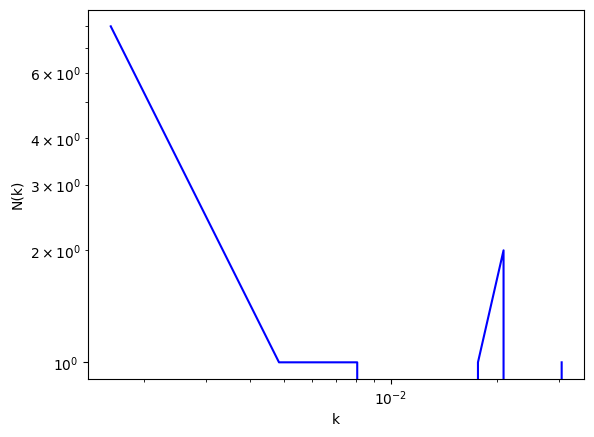

The power law exponent α is 1.6848382385163605
the power law fit p-value is 0.0204


In [76]:
R6_V6_in_pl_fit = degree_distribution(in_deg[np.intersect1d(R6.index, V6.index)])
R6_V6_out_pl_fit = degree_distribution(out_deg[np.intersect1d(R6.index, V6.index)])

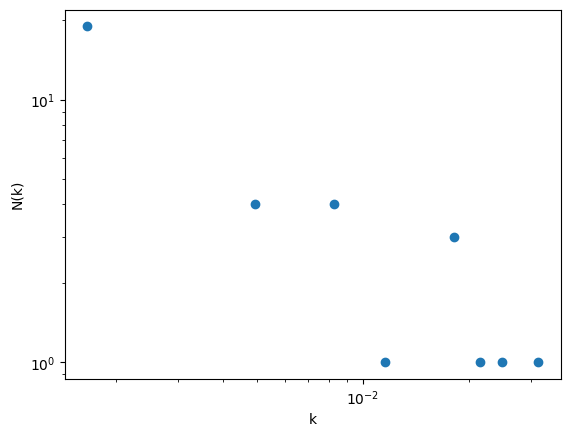

The power law exponent α is 1.9299522920512235
the power law fit p-value is 0.0212


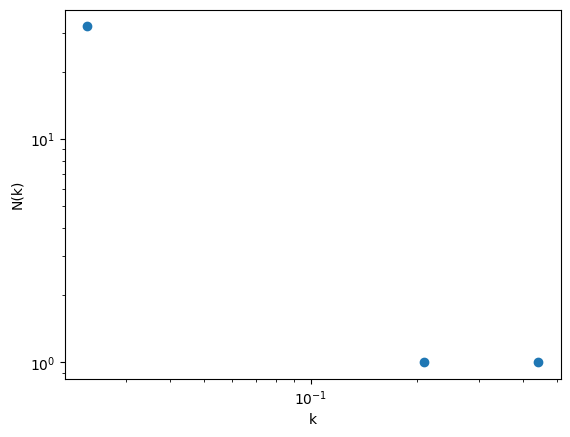

The power law exponent α is 1.4337069907870266
the power law fit p-value is 0.612


In [71]:
non_R6_V6_in_pl_fit = degree_distribution(in_deg[np.intersect1d(non_R6.index, V6.index)])
non_R6_V6_out_pl_fit = degree_distribution(out_deg[np.intersect1d(non_R6.index, V6.index)])

In [73]:
out_deg[np.intersect1d(non_R6.index, V6.index)]

in_deg[np.intersect1d(non_R6.index, V6.index)]

array([2.46381602e-03, 2.85680392e-03, 7.54872072e-03, 4.44530966e-03,
       3.66670132e-03, 3.93202529e-04, 1.00164252e-02, 5.90465291e-03,
       1.73695163e-02, 5.94824821e-05, 1.35994953e-04, 4.04858096e-11,
       2.30710333e-02, 3.30429598e-02, 1.33996062e-03, 2.42184471e-02,
       2.60715928e-04, 2.51787121e-04, 3.32663228e-04, 4.88952549e-04,
       6.25545063e-08, 1.91550470e-04, 1.66436492e-03, 4.63446937e-20,
       8.56271533e-20, 1.72203210e-19, 1.56489249e-19, 3.36076971e-19,
       1.76174147e-02, 1.84172784e-02, 7.20099872e-03, 6.85792994e-03,
       3.95650625e-03, 6.79409318e-03])

In [61]:
np.intersect1d(non_R6.index, V6.index).shape

(34,)

In [62]:
R6.index.shape

(27,)

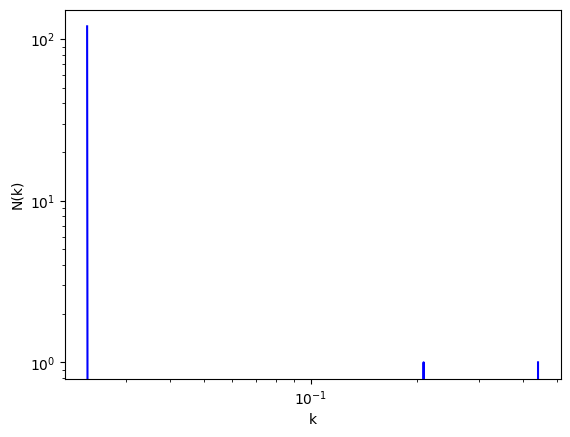

The power law exponent α is 1.5537115725434456
the power law fit p-value is 0.0988


FittedPowerLaw(continuous=True, alpha=1.5537115725434456, xmin=0.0016937565373396533, L=56.69031248833151, D=0.15708384386496665, p=0.0988)

In [77]:
degree_distribution(out_deg)